In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Connect and load Hyderabad data
engine = create_engine('postgresql://postgres@localhost:5432/india_air_quality')
df = pd.read_sql("SELECT date, aqi FROM city_day WHERE city = 'Hyderabad' AND aqi IS NOT NULL", engine)

# Prophet requires columns named 'ds' and 'y'
df = df.rename(columns={'date': 'ds', 'aqi': 'y'})
df['ds'] = pd.to_datetime(df['ds'])

print(df.shape)
df.head()

Importing plotly failed. Interactive plots will not work.


(1880, 2)


,ds,y
0,2015-03-31,120.0
1,2015-04-01,112.0
2,2015-04-06,141.0
3,2015-04-07,197.0
4,2015-04-08,177.0


In [2]:
# Train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(df)

# Forecast through 2030
future = model.make_future_dataframe(periods=365*10, freq='D')
forecast = model.predict(future)

print("Forecast generated successfully")
print(f"Forecast runs from {forecast['ds'].min()} to {forecast['ds'].max()}")


14:49:42 - cmdstanpy - INFO - Chain [1] start processing
14:49:44 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated successfully
Forecast runs from 2015-03-31 00:00:00 to 2030-06-29 00:00:00


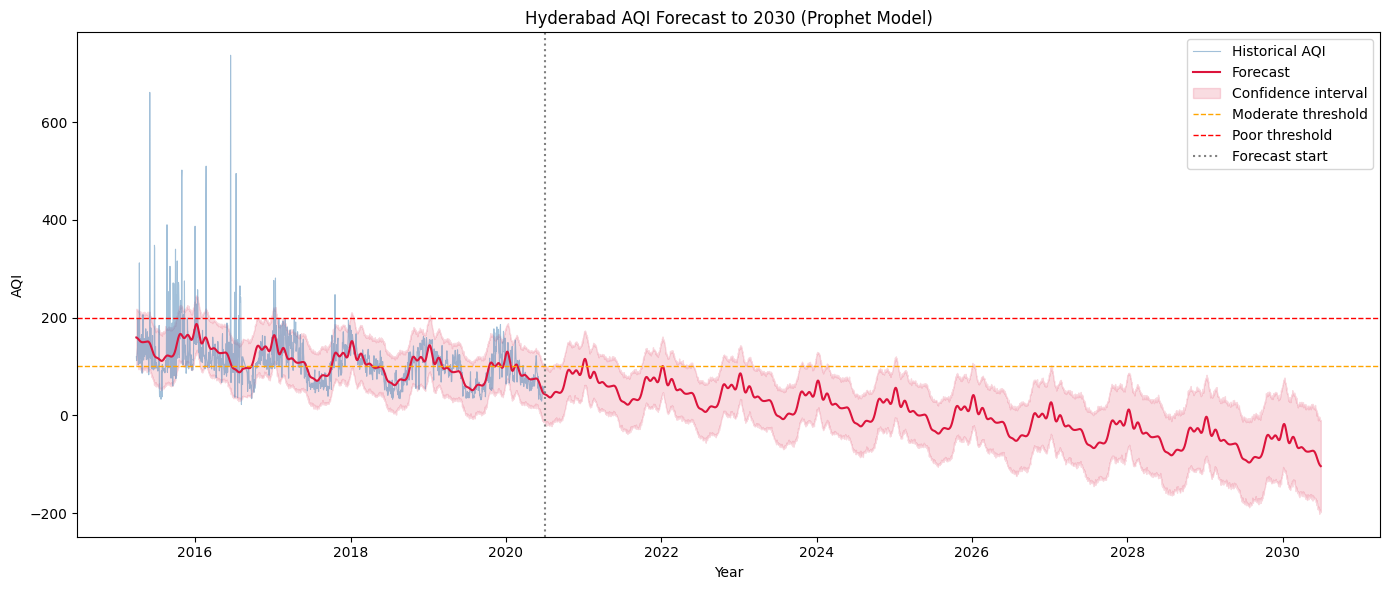

Predicted average AQI for Hyderabad in 2030: -63.6


In [3]:
# Plot the forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(df['ds'], df['y'], color='steelblue', alpha=0.5, linewidth=0.8, label='Historical AQI')

# Forecast
future_only = forecast[forecast['ds'] > df['ds'].max()]
ax.plot(forecast['ds'], forecast['yhat'], color='crimson', linewidth=1.5, label='Forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                color='crimson', alpha=0.15, label='Confidence interval')

# Reference lines
ax.axhline(y=100, color='orange', linestyle='--', linewidth=1, label='Moderate threshold')
ax.axhline(y=200, color='red', linestyle='--', linewidth=1, label='Poor threshold')
ax.axvline(x=pd.Timestamp('2020-07-01'), color='gray', linestyle=':', label='Forecast start')

ax.set_title('Hyderabad AQI Forecast to 2030 (Prophet Model)')
ax.set_xlabel('Year')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/hyderabad_aqi_forecast_2030.png', dpi=150)
plt.show()

# Print 2030 prediction
pred_2030 = forecast[forecast['ds'].dt.year == 2030]['yhat'].mean()
print(f"Predicted average AQI for Hyderabad in 2030: {pred_2030:.1f}")


14:51:13 - cmdstanpy - INFO - Chain [1] start processing
14:51:13 - cmdstanpy - INFO - Chain [1] done processing


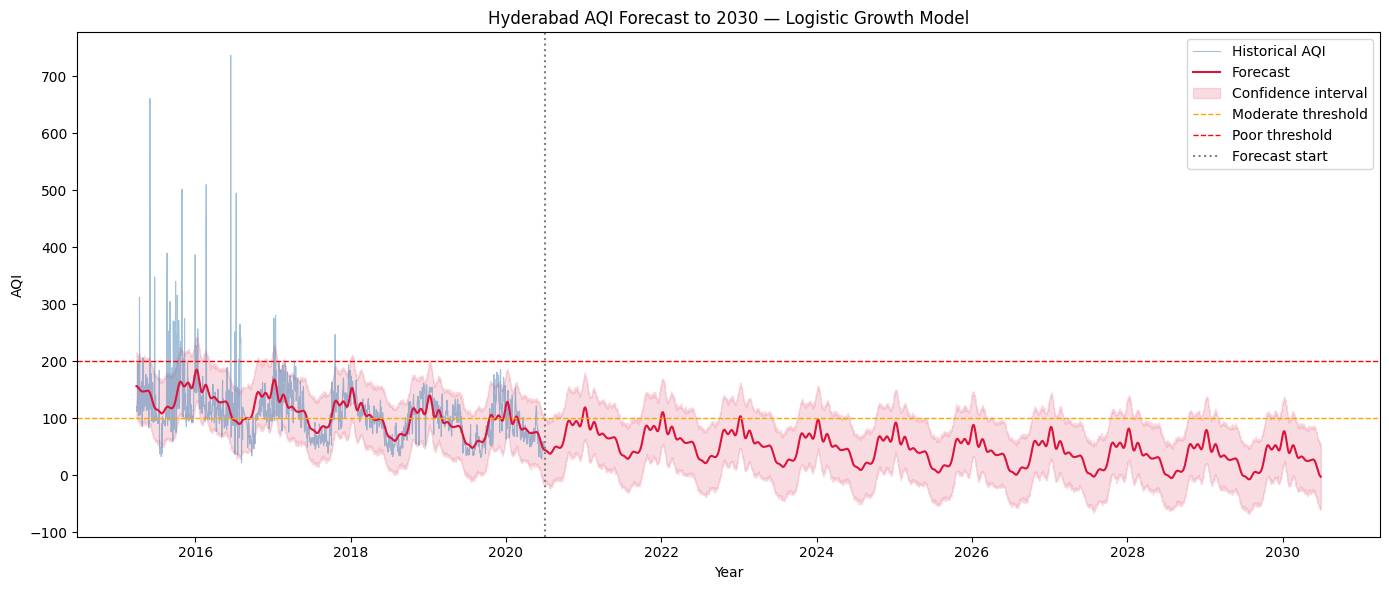

Predicted average AQI for Hyderabad in 2030: 34.9


In [4]:
# Retrain with floor and cap to keep predictions realistic
df['floor'] = 20
df['cap'] = 500

model2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    growth='logistic'
)

model2.fit(df)

future2 = model2.make_future_dataframe(periods=365*10, freq='D')
future2['floor'] = 20
future2['cap'] = 500

forecast2 = model2.predict(future2)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['ds'], df['y'], color='steelblue', alpha=0.5, linewidth=0.8, label='Historical AQI')
ax.plot(forecast2['ds'], forecast2['yhat'], color='crimson', linewidth=1.5, label='Forecast')
ax.fill_between(forecast2['ds'], forecast2['yhat_lower'], forecast2['yhat_upper'],
                color='crimson', alpha=0.15, label='Confidence interval')
ax.axhline(y=100, color='orange', linestyle='--', linewidth=1, label='Moderate threshold')
ax.axhline(y=200, color='red', linestyle='--', linewidth=1, label='Poor threshold')
ax.axvline(x=pd.Timestamp('2020-07-01'), color='gray', linestyle=':', label='Forecast start')
ax.set_title('Hyderabad AQI Forecast to 2030 — Logistic Growth Model')
ax.set_xlabel('Year')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/hyderabad_aqi_forecast_2030.png', dpi=150)
plt.show()

pred_2030 = forecast2[forecast2['ds'].dt.year == 2030]['yhat'].mean()
print(f"Predicted average AQI for Hyderabad in 2030: {pred_2030:.1f}")

14:51:53 - cmdstanpy - INFO - Chain [1] start processing
14:51:53 - cmdstanpy - INFO - Chain [1] done processing


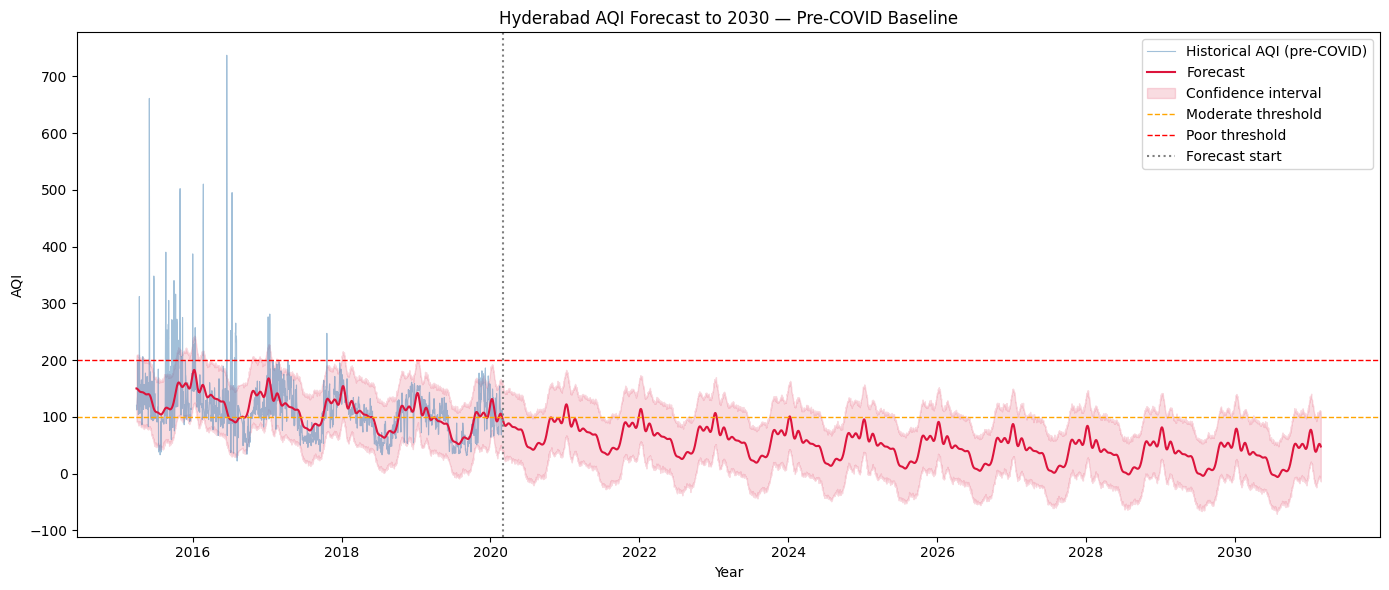

Predicted average AQI for Hyderabad in 2030: 30.9


In [5]:
# Remove COVID period (post March 2020) from training
df_precovid = df[df['ds'] < '2020-03-01'].copy()

model3 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    growth='logistic'
)

df_precovid['floor'] = 20
df_precovid['cap'] = 500

model3.fit(df_precovid)

future3 = model3.make_future_dataframe(periods=365*11, freq='D')
future3['floor'] = 20
future3['cap'] = 500

forecast3 = model3.predict(future3)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_precovid['ds'], df_precovid['y'], color='steelblue', alpha=0.5, linewidth=0.8, label='Historical AQI (pre-COVID)')
ax.plot(forecast3['ds'], forecast3['yhat'], color='crimson', linewidth=1.5, label='Forecast')
ax.fill_between(forecast3['ds'], forecast3['yhat_lower'], forecast3['yhat_upper'],
                color='crimson', alpha=0.15, label='Confidence interval')
ax.axhline(y=100, color='orange', linestyle='--', linewidth=1, label='Moderate threshold')
ax.axhline(y=200, color='red', linestyle='--', linewidth=1, label='Poor threshold')
ax.axvline(x=pd.Timestamp('2020-03-01'), color='gray', linestyle=':', label='Forecast start')
ax.set_title('Hyderabad AQI Forecast to 2030 — Pre-COVID Baseline')
ax.set_xlabel('Year')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/hyderabad_aqi_forecast_2030.png', dpi=150)
plt.show()

pred_2030 = forecast3[forecast3['ds'].dt.year == 2030]['yhat'].mean()
print(f"Predicted average AQI for Hyderabad in 2030: {pred_2030:.1f}")

In [6]:
# Extract year-by-year forecast summary
yearly_forecast = forecast3[forecast3['ds'].dt.month == 6].copy()
yearly_forecast['year'] = yearly_forecast['ds'].dt.year
yearly_forecast = yearly_forecast[yearly_forecast['year'] >= 2020][['year', 'yhat', 'yhat_lower', 'yhat_upper']]
yearly_forecast.columns = ['Year', 'Predicted_AQI', 'Lower_Bound', 'Upper_Bound']
yearly_forecast = yearly_forecast.round(1)

print(yearly_forecast.to_string(index=False))

 Year  Predicted_AQI  Lower_Bound  Upper_Bound
 2020           77.1         16.1        134.8
 2020           76.7         19.3        135.9
 2020           76.2         17.8        138.7
 2020           75.6         19.9        133.4
 2020           74.9         14.9        132.2
 2020           74.1         15.8        137.2
 2020           73.2         16.7        135.6
 2020           72.2         14.0        132.1
 2020           71.1         10.0        131.7
 2020           69.9         11.9        126.6
 2020           68.6         11.9        128.9
 2020           67.3          6.6        129.7
 2020           65.9          6.8        121.6
 2020           64.5          7.2        123.6
 2020           63.0          6.3        124.9
 2020           61.6         10.2        124.1
 2020           60.2         -1.0        114.6
 2020           58.7         -2.6        113.4
 2020           57.4         -0.1        117.0
 2020           56.0         -3.1        117.0
 2020        

In [7]:
# Clean yearly summary
yearly_summary = forecast3.copy()
yearly_summary['year'] = yearly_summary['ds'].dt.year
yearly_summary = yearly_summary.groupby('year').agg(
    Predicted_AQI=('yhat', 'mean'),
    Lower_Bound=('yhat_lower', 'mean'),
    Upper_Bound=('yhat_upper', 'mean')
).round(1).reset_index()

# Filter from 2020 onwards
yearly_summary = yearly_summary[yearly_summary['year'] >= 2020]
print(yearly_summary.to_string(index=False))

 year  Predicted_AQI  Lower_Bound  Upper_Bound
 2020           79.6         21.4        138.0
 2021           70.7         12.3        129.0
 2022           63.1          4.7        121.3
 2023           56.5         -1.9        114.9
 2024           51.0         -7.5        109.4
 2025           46.0        -12.4        104.4
 2026           41.9        -16.4        100.4
 2027           38.5        -20.1         97.1
 2028           35.6        -22.9         94.2
 2029           33.0        -25.4         91.6
 2030           30.9        -27.5         89.4
 2031           54.9         -3.6        113.4
